In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download Apple stock data from Yahoo Finance API
# Returns data as Pandas DataFrame
data = yf.download("AAPL",start="2023-01-01",end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096008,128.833987,122.210212,128.223777,112117500
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600
2023-01-05,123.046814,125.753411,122.790923,125.123513,80962700
2023-01-06,127.574203,128.233627,122.918861,124.021187,87754700
2023-01-09,128.095856,131.304413,127.839965,128.410812,70790800


In [4]:
# Check total rows and columns in dataset
print("Dataset Shape: ",data.shape)

Dataset Shape:  (250, 5)


In [5]:
# Check missing values in each column
print("Missing Values: ",data.isnull().sum())

Missing Values:  Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [6]:
# Check duplicate rows in dataset
print("Duplication of Rows data: ",data.duplicated().sum())

Duplication of Rows data:  0


In [7]:
# Check structure, data types and non-null counts
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 250 entries, 2023-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [8]:
# Check statistical summary of all numeric columns
print("Statistic Summary of dataset: ")
data.describe()

Statistic Summary of dataset: 


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,170.351416,171.642983,168.804713,170.063141,5.922355e+07
std,17.324152,17.256063,17.522304,17.519916,1.778332e+07
min,123.046814,125.753411,122.210212,124.021187,2.404830e+07
25%,159.797489,160.068562,158.405156,159.247945,4.781208e+07
50%,173.442329,174.974387,171.826252,173.214997,5.511085e+07
75%,185.253353,185.885945,182.783132,184.392079,6.574292e+07
max,196.073090,197.567559,194.974519,195.984019,1.543573e+08


In [9]:
print("Columns Names: ")
data.columns

Columns Names: 


MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [10]:
# X (Features) : Open, High, Low, Volume columns
# These are input values for model
X = data.drop(columns=['Close'])
# Y (Target)   : Close column
# This is the value model will predict
Y = data['Close']

print("Features :",data.drop(columns=['Close']).columns.tolist())
print("Target   : Close Price")

Features : [('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]
Target   : Close Price


In [11]:
# - StandardScaler : Removes mean and scales to unit variance
# - fit_transform  : Learns mean/std then transforms data
# - Why Scale      : Volume is in millions, others in dollars
#   Scaling brings all features to same range
#   Makes model training faster and accurate
# - Before Scaling : Open=130.28, Volume=112117500
# - After Scaling  : Open=0.23,   Volume=-0.45

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# All feature values now between -3 and +3 approximately

In [12]:
# SPLIT DATA INTO TRAINING AND TESTING SETS
# - test_size=0.2   : 20% data used for testing
#                     80% data used for training
# - random_state=42 : Fixed seed for reproducibility
#                     Same split every time code runs
# - Total Data      : 250 rows
# - Training Data   : 200 rows → Model learns from this
# - Testing Data    :  50 rows → Model evaluated on this
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
print("Training Shape: ",X_train.shape)
print("Testing shape: : ",X_test.shape)

Training Shape:  (200, 4)
Testing shape: :  (50, 4)


In [13]:
# LINEAR REGRESSION MODEL
# - LinearRegression : Finds best straight line through data
from sklearn.linear_model import LinearRegression
# Create Linear Regression model object
Lr_model = LinearRegression()
# Train model using training data
# Model learns pattern between features and Close price
Lr_model.fit(X_train,Y_train)
# Predict Close prices for test data
# Returns array of predicted closing prices
Lr_predicted = Lr_model.predict(X_test)

In [14]:
# MODEL EVALUATION
from sklearn.metrics import mean_squared_error,r2_score
print("Linear Regression Accuracy")
# - Accuracy: Percentage of correct predictions
#   Higher is better → Close to 100% best
print("Accuracy:",Lr_model.score(X_test,Y_test)*100)
# - mean_squared_error : Average squared difference
#   between actual and predicted values
#   Lower is better → Close to 0 is best
Lr_mse = mean_squared_error(Y_test,Lr_predicted)
print("Mean Squared Error: ",Lr_mse)
# - r2_score: How well model fits the data
#   Higher is better → Close to 1 is best
R2_Score = r2_score(Y_test,Lr_predicted)
print("R2 Score: ",R2_Score)

Linear Regression Accuracy
Accuracy: 99.8026032102745
Mean Squared Error:  0.6329124046504644
R2 Score:  0.998026032102745


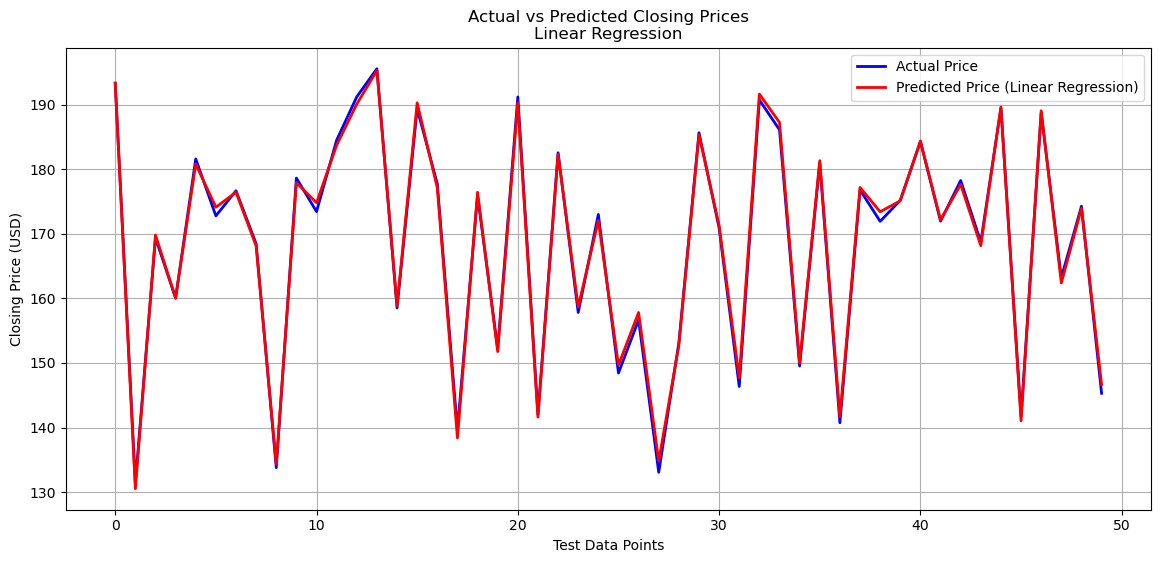

In [15]:
# Compares actual closing prices with
# Linear Regression predicted closing prices
plt.figure(figsize=(14, 6))
# Plot actual closing prices in blue solid line
plt.plot(Y_test.values,color='blue',label='Actual Price',linewidth=2)
# Plot predicted closing prices in red dashed line
plt.plot(Lr_predicted,color='red',label='Predicted Price (Linear Regression)',linewidth=2)

plt.title("Actual vs Predicted Closing Prices\n""Linear Regression")
plt.xlabel("Test Data Points")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# RANDOM FOREST REGRESSOR MODEL
# - RandomForest : Uses multiple decision trees for prediction
#                  More powerful than Linear Regression
from sklearn.ensemble import RandomForestRegressor
# Create Random Forest model object
Rf_model = RandomForestRegressor()
# Train model using training data
# Builds multiple decision trees on training data
Rf_model.fit(X_train,Y_train)
# Predict Close prices for test data
# Returns array of predicted closing prices
Rf_predicted = Rf_model.predict(X_test)

c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [17]:
from sklearn.metrics import mean_squared_error,r2_score
print("Random Forest Regressor Accuracy")
# Lower MSE means predictions are closer to actual values
Lr_mse = mean_squared_error(Y_test,Rf_predicted)
print("Mean Squared Error: ",Lr_mse)
# Higher R2 means model explains more variance in data
R2_Score = r2_score(Y_test,Rf_predicted)
print("R2 Score: ",R2_Score)

Random Forest Regressor Accuracy
Mean Squared Error:  1.4380808001463887
R2 Score:  0.9955148211469872


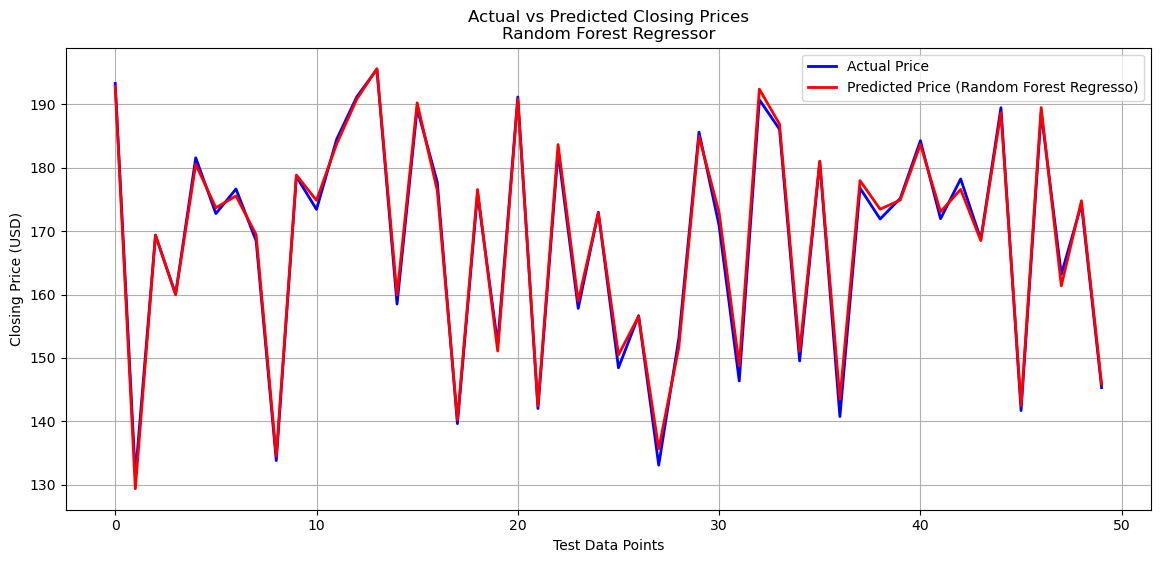

In [18]:
# Compares actual closing prices with
# Random Forest predicted closing prices
plt.figure(figsize=(14,6))
# Plot actual closing prices in blue solid line
plt.plot(Y_test.values,color='blue',label='Actual Price',linewidth=2)
# Plot predicted closing prices in green dashed line
plt.plot(Rf_predicted,color='red',label='Predicted Price (Random Forest Regresso)',linewidth=2)

plt.title("Actual vs Predicted Closing Prices\n""Random Forest Regressor")
plt.xlabel("Test Data Points")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()